# Import Library

In [271]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Load Dataset

In [272]:
df = pd.read_csv('Dataset/Mall_Customers.csv')

In [273]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# Exploratory Data Analysis

In [274]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [275]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [276]:
print("Missing value pada tiap fitur:")
print(df.isnull().sum())

Missing value pada tiap fitur:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


In [277]:
print("Jumlah data duplikat: ", df.duplicated().sum())

Jumlah data duplikat:  0


In [278]:
df = df.drop(columns=['Age','Gender', 'CustomerID'])

In [279]:
df.head()

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


# Preprocessing

In [280]:
scaler = StandardScaler()

In [281]:
X = scaler.fit_transform(df)

# Menentukan Jumlah Cluster

Gunakan Kmeans sebagai baseline

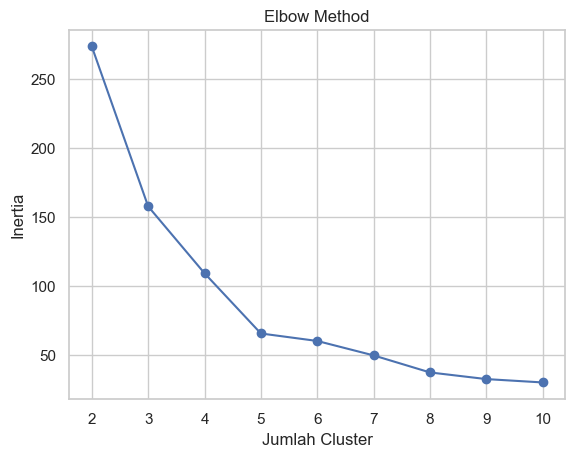

In [282]:
inertia = []

K = range(2,11)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.plot(K, inertia, marker='o')
plt.xlabel('Jumlah Cluster')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [283]:
from sklearn.metrics import silhouette_score

best_score = -1
best_k = 0
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"Cluster {k} = Silhouette Score = {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print(f"\nJumlah cluster terbaik: {best_k} dengan Silhouette Score = {best_score:.4f}")

Cluster 2 = Silhouette Score = 0.3973
Cluster 3 = Silhouette Score = 0.4666
Cluster 4 = Silhouette Score = 0.4943
Cluster 5 = Silhouette Score = 0.5547
Cluster 6 = Silhouette Score = 0.5138
Cluster 7 = Silhouette Score = 0.5020
Cluster 8 = Silhouette Score = 0.4550
Cluster 9 = Silhouette Score = 0.4567
Cluster 10 = Silhouette Score = 0.4448

Jumlah cluster terbaik: 5 dengan Silhouette Score = 0.5547


# Modelling

## KMeans

In [284]:
clusterNum = 6
k_means = KMeans(init = "k-means++", n_clusters = clusterNum, random_state=42)
k_means.fit(X)

KMeans(n_clusters=6, random_state=42)

In [285]:
kmeans_predictions = k_means.predict(X)

In [286]:
k_means_labels = k_means.labels_
k_means_labels

array([5, 2, 4, 2, 5, 2, 4, 2, 4, 2, 4, 2, 4, 2, 4, 2, 5, 2, 5, 2, 5, 2,
       4, 2, 4, 2, 5, 2, 5, 2, 4, 2, 4, 2, 4, 2, 4, 2, 5, 2, 5, 2, 5, 0,
       5, 2, 0, 5, 5, 5, 0, 0, 0, 0, 0, 5, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 3, 1, 0, 1, 3, 1, 3, 1,
       0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 0, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1, 3, 1,
       3, 1], dtype=int32)

In [287]:
k_means_cluster_centers = k_means.cluster_centers_
k_means_cluster_centers

array([[-0.17206977, -0.01331025],
       [ 0.99158305,  1.23950275],
       [-1.32954532,  1.13217788],
       [ 1.05500302, -1.28443907],
       [-1.37320883, -1.57680239],
       [-1.1079313 , -0.55644237]])

In [288]:
sil_score = silhouette_score(X, kmeans_predictions)
sil_score

np.float64(0.5138257534676561)

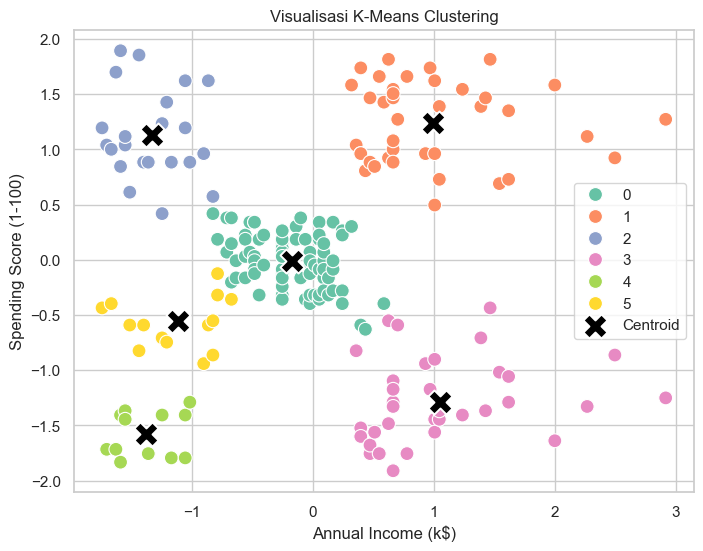

In [290]:
df_plot = pd.DataFrame(X, columns=["Annual Income (k$)", "Spending Score (1-100)"])
df_plot["Cluster"] = kmeans_predictions

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_plot,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    hue="Cluster",
    palette="Set2",
    s=100
)

centers = pd.DataFrame(k_means_cluster_centers, columns=["Annual Income (k$)", "Spending Score (1-100)"])
sns.scatterplot(
    data=centers,
    x="Annual Income (k$)",
    y="Spending Score (1-100)",
    s=300,
    color="black",
    marker="X",
    label="Centroid"
)

plt.title("Visualisasi K-Means Clustering")
plt.legend()
plt.show()

In [ ]:
from sklearn.metrics import silhouette_score

# menghitung silhouette score
score = silhouette_score(X, k_means.labels_)
print("Silhouette Score:", score)

Silhouette Score: 0.43106526216603014


In [ ]:
from sklearn.metrics import silhouette_score

best_score = -1
best_k = 0
for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    print(f"Cluster {k} = Silhouette Score = {score:.4f}")

    if score > best_score:
        best_score = score
        best_k = k

print(f"\nJumlah cluster terbaik: {best_k} dengan Silhouette Score = {best_score:.4f}")

Cluster 2 = Silhouette Score = 0.3355
Cluster 3 = Silhouette Score = 0.3579


Cluster 4 = Silhouette Score = 0.4040
Cluster 5 = Silhouette Score = 0.4085
Cluster 6 = Silhouette Score = 0.4311
Cluster 7 = Silhouette Score = 0.4101
Cluster 8 = Silhouette Score = 0.3674
Cluster 9 = Silhouette Score = 0.3744
Cluster 10 = Silhouette Score = 0.3619

Jumlah cluster terbaik: 6 dengan Silhouette Score = 0.4311
